# Machine Learning na prática
## Previsão de Churn de Clientes

Fluxo do projeto:
1. Explorar dados
2. Preparar dados
3. Treinar modelo
4. Avaliar desempenho

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**1. Vamos primeiro inserir nosso dataset.**
Temos várias formas de fazer isso, vamos hoje subir o arquivo direto do Kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: /home/carlosdelfino/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [11]:
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


***Pergunta:***

Cada linha representa o que?

**2. Vamos explorar os dados**

In [12]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

***Perguntas:***

- Quantos clientes temos?
- Quantas variáveis?
- Quais tipos?

Vamos visualizar quantos dados tempos para "Sim" e "Não":

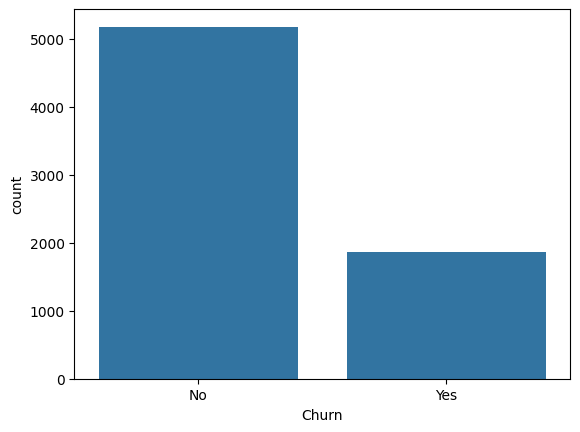

In [13]:
sns.countplot(x='Churn', data=df)
plt.show()

**Pergunta:**

Temos mais clientes que cancelam ou que permanecem?

**3. Selecionando dados para realização da análise.**

In [14]:
df = df.drop('customerID', axis=1) #Vamos remover o identificador dos clientes para que o ID não atrapalhe a análise. O que acha? Importa saber o nome do cliente?
df['Churn'] = df['Churn'].map({'Yes':1,'No':0}) #Aqui vamos atribuír números ao SIM ou NÂO. 1-cancelou e 0-não cancelou

# Correção: Converter TotalCharges para numérico e tratar valores ausentes
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)  # Preencher valores ausentes com 0

df = pd.get_dummies(df, drop_first=True)  #Aqui estamos transformando as variáveis categóricas em variáveis binárias, o modelo não entende casado e solteiro, mas entende 0 ou 1.

**Tarefa:**
Compare o dataframe antes e depois da aplicação de get_dummies.

Dica, utilize:
df.columns
df.shape


1. O número de colunas aumentou ou diminuiu?


2. Foram criadas novas colunas?


3. Quais são os nomes dessas colunas novas?


4. Observe o padrão dos nomes das novas colunas.

Exemplo típico:
Contract_Two year
InternetService_Fiber optic
PaymentMethod_Electronic check

O que esses nomes representam?


5. Analise os valores dentro dessas colunas.


Dica, utilize:
df[['Contract_Two year']].head()

Que valores aparecem nessas colunas?

O que significa 0 e 1?


6. Reflexão final:

**Reflita:**

Por que precisamos transformar variáveis categóricas em colunas numéricas antes de treinar um modelo de Machine Learning?


*Dica para exploração adicional*

Tente identificar uma coluna categórica do dataset original (por exemplo Contract) e ver como ela foi representada após o get_dummies.

In [15]:
X = df.drop('Churn', axis=1)
y = df['Churn']

Aqui estamos separando o problema de aprendizado em duas partes:
Tipo	Conteúdo
X	variáveis que explicam o problema
y	variável que queremos prever

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

O que estamos fazendo?

Dividimos os dados em duas partes:
Conjunto	Função
treinamento	ensinar o modelo
teste	avaliar o modelo

**Perguntas**:

Qual a porcentagem de treinamento e de teste?

Qual o risco de utilizar 100% dos dados para treinamento?

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Aqui estamos normalizando as variáveis para tirar o "peso" dos valores absolutos delas.

In [19]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**Pergunta**:
O que representa o argumento max_iter=1000.

In [20]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.8204400283889283

Aqui temos a acurácia do molelo, note que estamos comparando o teste (y_test) com os valores previstos (y_pred). A variável y_pred é obtida pelo model.predict() com os dados de teste (X_test)

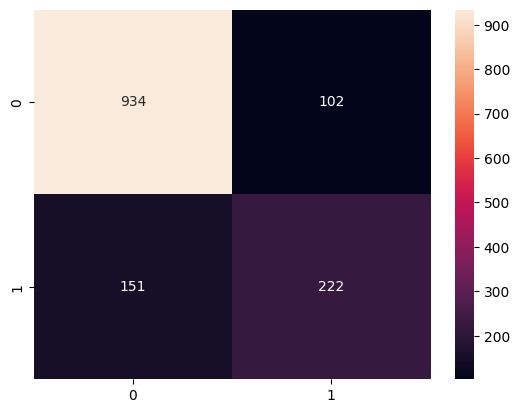

In [21]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

**Já rodamos o modelo agora vamos calcular:**

- Calcule a precisão (% de acerto da classe, quantos sim ou não realmente acertou)
- Calcule o recall (% de acertos dos casos, clientes que cancelaram ou não)
- Calcule F1-score (média harmônica entre precisão e recall)

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



**Reflita**

Por qual motivo os casos de desistência (churn: valor 1, sim) pode ter apresentado desempenho menor no processo de classificação?